In [1]:
import sys
import joblib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
if project_root not in sys.path:
    sys.path.append(project_root)

from src.xgboost import XGBoostRegressor as CustomXGBoost


In [2]:
train_path = os.path.join(project_root, 'data', 'train.csv')
val_path   = os.path.join(project_root, 'data', 'val.csv')
test_path  = os.path.join(project_root, 'data', 'test.csv')

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)

In [3]:
target_col = 'Calories'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

X_val = df_val.drop(columns=[target_col])
y_val = df_val[target_col]

c:\Users\User\Desktop\Matt Folder\DeleteSoon\CS115_Tree_Project\venv\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


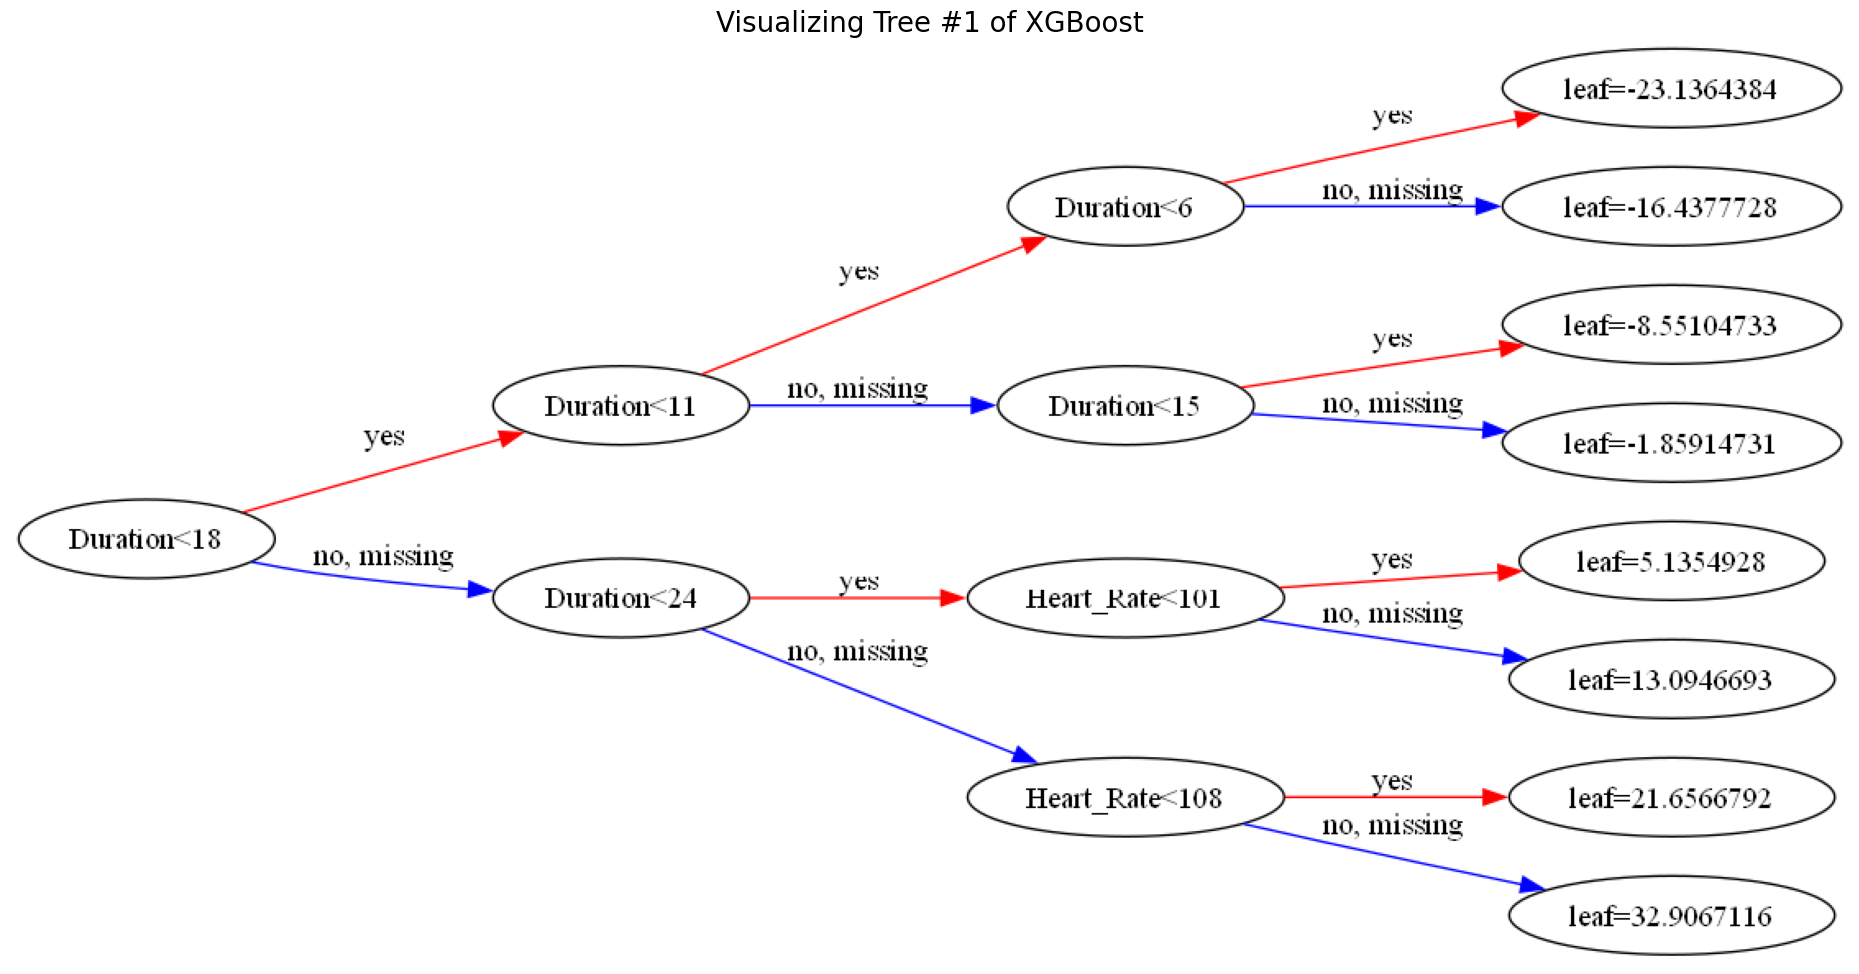

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Initialize a "Visualization" Model
viz_model = xgb.XGBRegressor(n_estimators=10, max_depth=3, random_state=42)

# 2. Fit on your Training Data
viz_model.fit(X_train, y_train)

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(24, 12))

# 4. Plot the FIRST tree (num_trees=0)
xgb.plot_tree(viz_model, num_trees=0, ax=ax, rankdir='LR') # LR = Left-to-Right

plt.title("Visualizing Tree #1 of XGBoost", fontsize=20)
plt.show()

In [4]:
lib_model = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    min_child_weight = 5,
    gamma = 1,
    reg_lambda = 1.5,
    colsample_bytree = 0.8,
    random_state = 42
)

lib_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_val['Gender'] = le.fit_transform(X_val['Gender'])

In [6]:
# Predict on Validation Set
y_pred_lib = lib_model.predict(X_val)

In [7]:
custom_model = CustomXGBoost()

custom_model.fit(
    X_train,
    y_train,
    subsample_cols=0.8,
    min_child_weight=5,
    depth=5,
    learning_rate=0.1,
    boosting_rounds=100,
    gamma=1,
    lambda_=1.5,
    min_leaf=0,
    eps=0.1
)

In [8]:
if not os.path.exists('models'):
    os.makedirs('models')

In [9]:
joblib.dump(custom_model, 'models/scratch_xgboost.pkl')

['models/scratch_xgboost.pkl']

In [10]:
# Predict
y_pred_custom = custom_model.predict(X_val)

In [11]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}

In [12]:
stats_lib = evaluate_model("Library XGBoost", y_val, y_pred_lib)
stats_custom = evaluate_model("Custom XGBoost (Scratch)", y_val, y_pred_custom)

In [13]:
comparison_df = pd.DataFrame([stats_lib, stats_custom])
comparison_df

,Model,RMSE,MAE,R2 Score
0,Library XGBoost,2.139216,1.514875,0.998803
1,Custom XGBoost (Scratch),2.449612,1.643002,0.998431
